In [2]:
import os
import math
import csv

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, resample
from scipy.interpolate import CubicSpline
from pyampd.ampd import find_peaks

In [3]:
# ---- CONFIG ----
input_folder = r"0_subject"       # folder with your raw .txt PPG files
output_folder = r"0_subject_clean"  # cleaned signals get written here

fs_original = 1000
fs_new = 125

os.makedirs(output_folder, exist_ok=True)

In [7]:
# ---- LOAD ALL RAW SIGNALS ----
signals = {}
lengths = []

for file in sorted(os.listdir(input_folder)):
    if file.endswith(".txt"):
        path = os.path.join(input_folder, file)
        signal = np.loadtxt(path)
        signals[file] = signal
        lengths.append(len(signal))

print("Total signals:", len(signals))
print("First file:", list(signals.keys())[0])
print("Length:", lengths[0])

Total signals: 657
First file: 100_1.txt
Length: 2100


In [8]:
# ---- PIPELINE FUNCTIONS (same steps as eda.ipynb, wrapped for reuse) ----

def downsample(sig, fs_original=1000, fs_new=125):
    num_samples = int(len(sig) * fs_new / fs_original)
    return resample(sig, num_samples)


def bandpass_filter(sig, fs, lowcut=0.7, highcut=12, order=4):
    nyquist = fs / 2
    b, a = butter(N=order, Wn=[lowcut / nyquist, highcut / nyquist], btype="band")
    return filtfilt(b, a, sig)


def detect_peaks_valleys(sig, fs):
    """Returns (peak_idx, valley_idx), boundary points stripped."""
    pks = find_peaks(sig, fs)
    if len(pks) > 0:
        if pks[0] == 0:
            pks = pks[1:]
        if len(pks) > 0 and pks[-1] == len(sig) - 1:
            pks = pks[:-1]

    vlys = find_peaks(-sig, fs)
    if len(vlys) > 0:
        if vlys[0] == 0:
            vlys = vlys[1:]
        if len(vlys) > 0 and vlys[-1] == len(sig) - 1:
            vlys = vlys[:-1]

    return pks, vlys


def estimate_baseline(sig, valley_idx):
    """Cubic-spline baseline through the valleys, with head/tail extrapolation
    points added (median-spaced) so the spline covers the full signal length."""
    rollingmin_idx = valley_idx
    rollingmin = sig[valley_idx]

    mean = np.mean(rollingmin)
    dist = np.median(np.diff(rollingmin_idx))
    med = np.median(rollingmin)

    add_pts_head = math.ceil(rollingmin_idx[0] / dist)
    head_d = [rollingmin_idx[0] - i * dist for i in reversed(range(1, add_pts_head + 1))]
    head_m = [med] * add_pts_head

    add_pts_tail = math.ceil((len(sig) - rollingmin_idx[-1]) / dist)
    tail_d = [rollingmin_idx[-1] + i * dist for i in range(1, add_pts_tail + 1)]
    tail_m = [med] * add_pts_tail

    full_idx = np.concatenate((head_d, rollingmin_idx, tail_d))
    full_vals = np.concatenate((head_m, rollingmin, tail_m))

    cs = CubicSpline(full_idx, full_vals)
    baseline = cs(np.arange(len(sig)))
    return baseline, mean


def process_one_signal(raw_signal, fs_original=1000, fs_new=125):
    """Runs the full pipeline on one raw signal, returns the corrected signal.
    Raises ValueError if too few valleys are found to build a spline baseline."""
    signal_ds = downsample(raw_signal, fs_original, fs_new)
    signal_filtered = bandpass_filter(signal_ds, fs_new)

    _, vlys = detect_peaks_valleys(signal_filtered, fs_new)

    if len(vlys) < 2:
        raise ValueError(f"Only {len(vlys)} valleys detected -- need >=2 for spline baseline")

    baseline, mean = estimate_baseline(signal_filtered, vlys)
    signal_corrected = signal_filtered - (baseline - mean)

    return signal_corrected

In [9]:
# ---- BATCH PROCESS ALL SIGNALS ----
log_rows = []
cleaned_signals = {}
n_ok, n_fail = 0, 0

for file, raw in signals.items():
    try:
        corrected = process_one_signal(raw, fs_original, fs_new)
        cleaned_signals[file] = corrected

        out_path = os.path.join(output_folder, file)
        np.savetxt(out_path, corrected)

        log_rows.append({"file": file, "status": "ok", "error": ""})
        n_ok += 1
    except Exception as e:
        log_rows.append({"file": file, "status": "failed", "error": str(e)})
        n_fail += 1
        print(f"[FAILED] {file}: {e}")

print(f"\nDone. {n_ok} succeeded, {n_fail} failed.")
print(f"Cleaned signals written to: {output_folder}")


Done. 657 succeeded, 0 failed.
Cleaned signals written to: 0_subject_clean


In [10]:
# ---- SAVE LOG ----
log_path = os.path.join(output_folder, "preprocessing_log.csv")
with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file", "status", "error"])
    writer.writeheader()
    writer.writerows(log_rows)

print("Log written to:", log_path)

Log written to: 0_subject_clean/preprocessing_log.csv


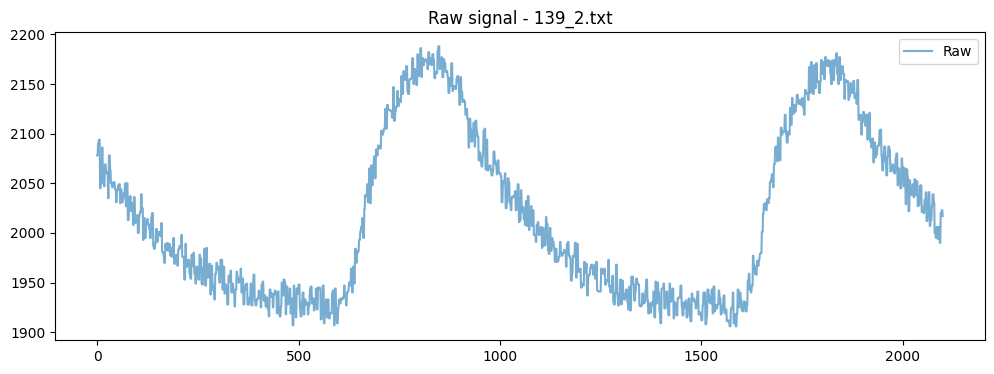

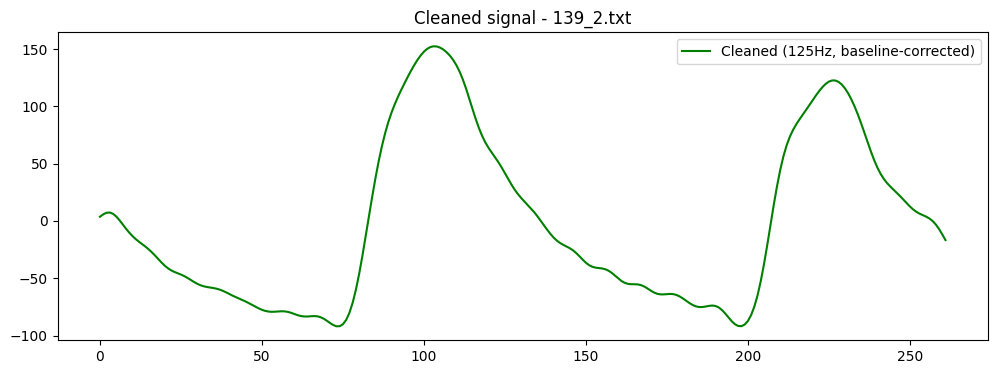

In [15]:
check_file = list(cleaned_signals.keys())[100]

plt.figure(figsize=(12, 4))
plt.plot(signals[check_file], label="Raw", alpha=0.6)
plt.title(f"Raw signal - {check_file}")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(cleaned_signals[check_file], label="Cleaned (125Hz, baseline-corrected)", color="green")
plt.title(f"Cleaned signal - {check_file}")
plt.legend()
plt.show()